In [11]:
import os

base_path = "../../output/protenn2/test_arch"
model_path = os.path.join(base_path, "best_model.pt")
label_encoder_path = os.path.join(base_path, "label_encoder.pkl")
data_path = '../../datasets/v3'

Libraries imported successfully.
`parse_cath` function defined.
`evaluate_hierarchical_metrics` function defined (with flexibility for 'NO_DOMAIN_REGION').
LabelEncoder loaded from ../../output/protenn2/test_arch/label_encoder.pkl
Number of classes: 804
Using device: mps
Loaded 31 validation proteins.
Max protein length: 599
Max protein length used for padding: 599
Validation DataLoader prepared.
Model weights loaded from ../../output/protenn2/test_arch/best_model.pt

--- Computing Metrics INCLUDING 'NO_DOMAIN_REGION' ---
Starting hierarchical metric computation (including 'NO_DOMAIN_REGION')...
Processed 100 batches...
Processed 200 batches...
Processed 300 batches...
Processed 400 batches...
Processed 500 batches...
Processed 600 batches...
Processed 700 batches...
Processed 800 batches...
Processed 900 batches...
Processed 1000 batches...
Processed 1100 batches...
Processed 1200 batches...
Processed 1300 batches...
Processed 1400 batches...
Processed 1500 batches...
Processed 1600 b

/var/folders/nf/_hy8vffs4dzc3cfg063rfz0w0000gn/T/ipykernel_58244/3660579293.py:323: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=accuracy_values, palette='viridis')


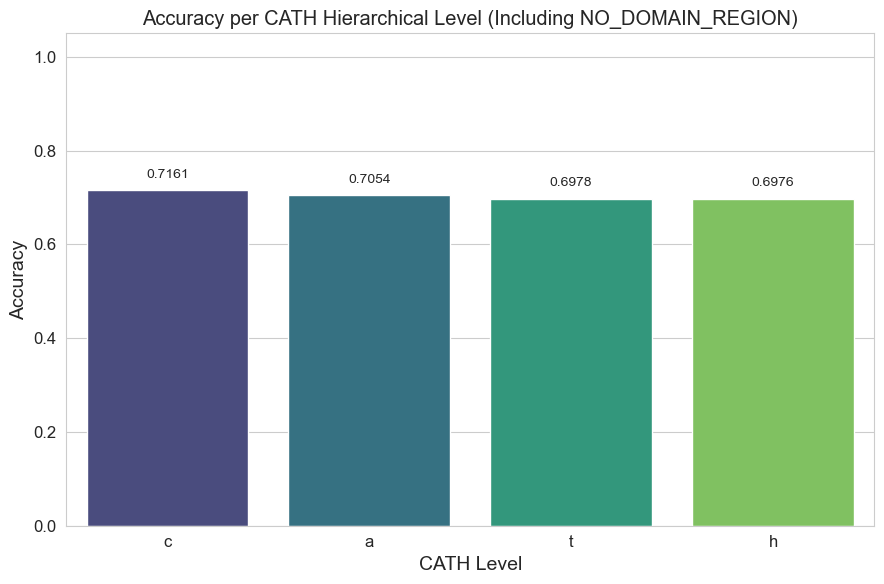

Accuracy bar chart saved to ../../output/protenn2/test_arch/plots/cath_accuracy_bar_chart_with_no_domain.png and displayed.


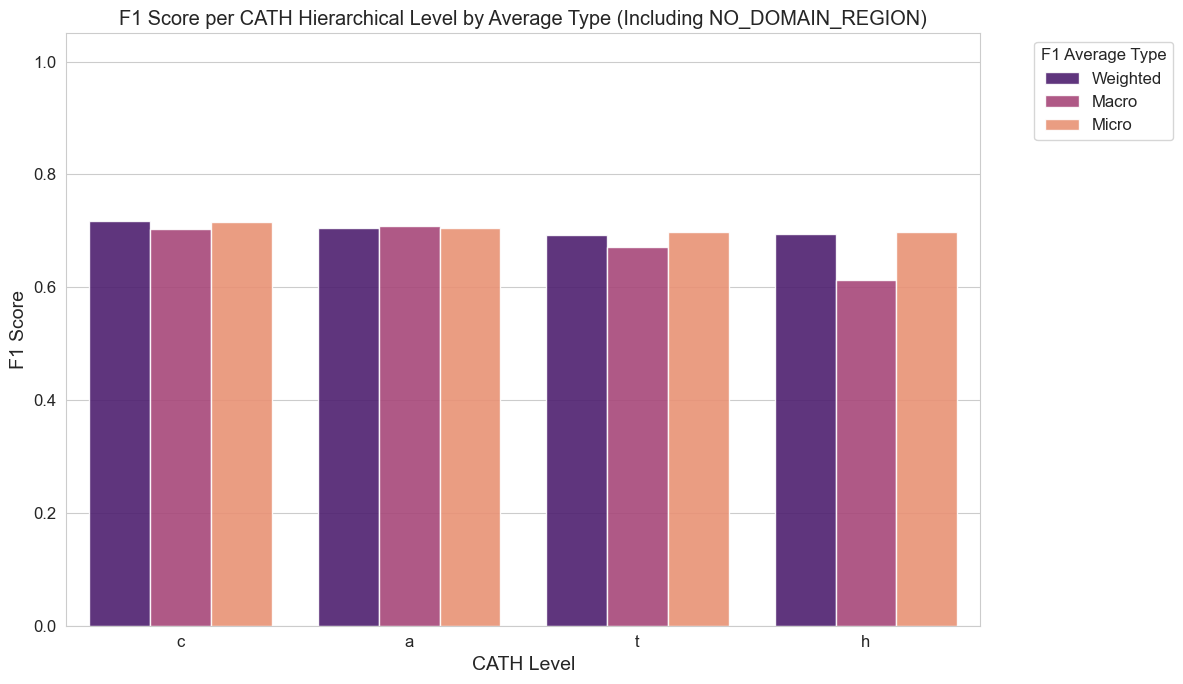

F1 score grouped bar chart saved to ../../output/protenn2/test_arch/plots/cath_f1_bar_chart_with_no_domain.png and displayed.


/var/folders/nf/_hy8vffs4dzc3cfg063rfz0w0000gn/T/ipykernel_58244/3660579293.py:323: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=levels, y=accuracy_values, palette='viridis')


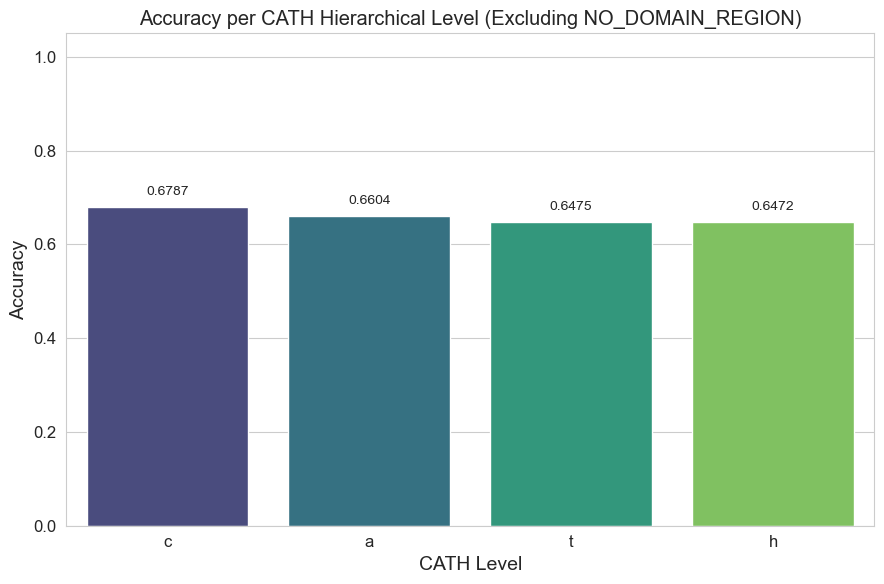

Accuracy bar chart saved to ../../output/protenn2/test_arch/plots/cath_accuracy_bar_chart_without_no_domain.png and displayed.


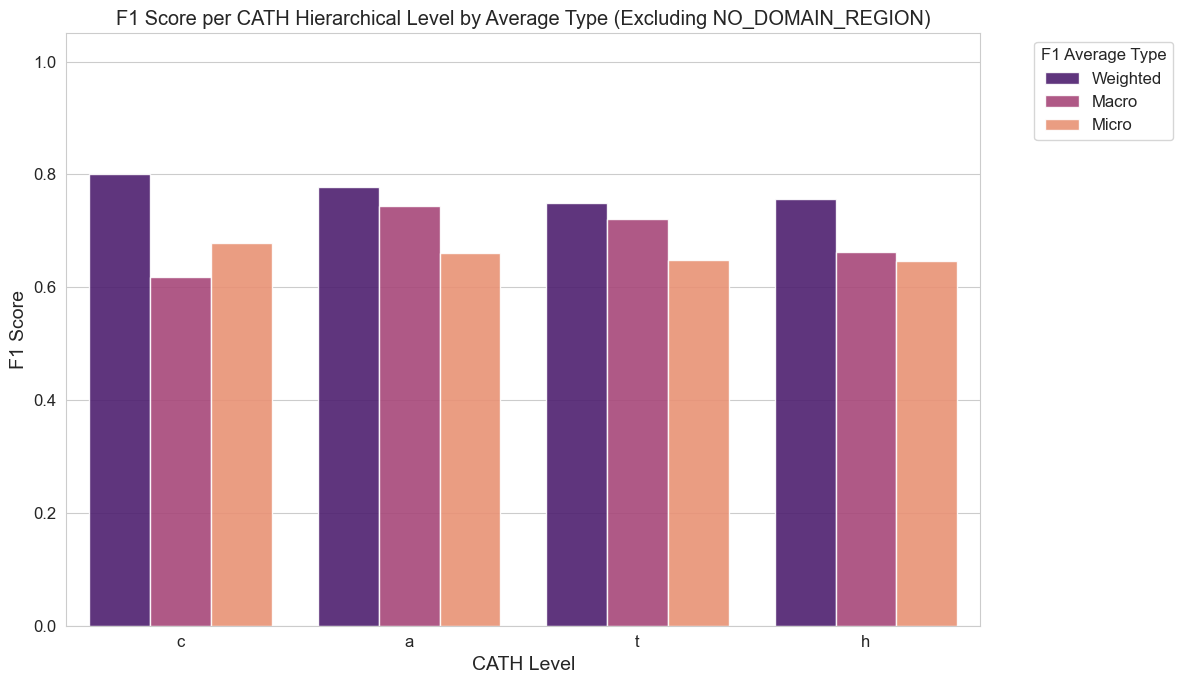

F1 score grouped bar chart saved to ../../output/protenn2/test_arch/plots/cath_f1_bar_chart_without_no_domain.png and displayed.
--- Visualization Complete ---


In [12]:
import os
import pickle
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your project structure or environment has these available:
from src.protenn2.model import CathPredEnn2
from src.protenn2.dataset import CathPredPerResidueDataset, create_protein_collate_fn
from src.protenn2.utils import get_train_val_test_paths, calculate_max_protein_length

print("Libraries imported successfully.")


# --- 2. Helper Function: CATH Parser ---
def parse_cath(cath_string):
    """
    Parses a CATH string (e.g., "3.30.559.10") into its components.
    Returns (Class, Architecture, Topology, Homologous Superfamily) as strings.
    If a component is missing, it returns 'N/A' for that part.
    Handles 'NO_DOMAIN_REGION' specifically by returning (None, None, None, None).
    """
    if cath_string == "NO_DOMAIN_REGION":
        return None, None, None, None  # Indicate no CATH hierarchy for this label

    parts = cath_string.split('.')

    # Ensure all 4 parts are returned, padding with 'N/A' if missing
    c = parts[0] if len(parts) > 0 else 'N/A'
    a = parts[1] if len(parts) > 1 else 'N/A'
    t = parts[2] if len(parts) > 2 else 'N/A'
    h = parts[3] if len(parts) > 3 else 'N/A'

    return c, a, t, h


print("`parse_cath` function defined.")


# --- 3. Evaluation Function (MODIFIED FOR FLEXIBILITY) ---
def evaluate_hierarchical_metrics(model, dataloader, label_encoder, device, padding_encoded_id,
                                  include_no_domain_region=True):
    """
    Evaluates the model's accuracy and F1-score at each CATH hierarchical level (C, A, T, H).
    Allows including or excluding 'NO_DOMAIN_REGION' as a distinct category.
    Only excludes padding residues regardless of 'include_no_domain_region'.
    """
    model.eval()  # Set model to evaluation mode
    id_to_label = {i: label for i, label in enumerate(label_encoder.classes_)}

    # Lists to store true and predicted hierarchical components for all *non-padding* residues
    all_true_c = []
    all_pred_c = []
    all_true_a = []
    all_pred_a = []
    all_true_t = []
    all_pred_t = []
    all_true_h = []
    all_pred_h = []

    mode_description = "including 'NO_DOMAIN_REGION'" if include_no_domain_region else "excluding 'NO_DOMAIN_REGION'"
    print(f"Starting hierarchical metric computation ({mode_description})...")

    with torch.no_grad():  # Disable gradient calculations for inference
        for batch_idx, (x, y_true_encoded, domain_id) in enumerate(dataloader):
            # Move data to the appropriate device (CPU or GPU)
            for k, v in x.items():
                x[k] = v.to(device, non_blocking=True)
            y_true_encoded = y_true_encoded.to(device, non_blocking=True)

            # Model inference
            outputs = model(x)
            outputs = outputs.permute(0, 2, 1)  # Reshape to (batch_size, seq_len, num_classes)
            y_pred_encoded = torch.argmax(outputs, dim=1)  # Get the predicted class ID

            # Process each sequence in the batch
            for sample_idx in range(x["embedding"].shape[0]):
                true_labels_ids = y_true_encoded[sample_idx].cpu().numpy()
                pred_labels_ids = y_pred_encoded[sample_idx].cpu().numpy()

                for residue_idx in range(len(true_labels_ids)):
                    true_label_id = true_labels_ids[residue_idx]

                    # --- ALWAYS EXCLUDE PADDED RESIDUES ---
                    if true_label_id == padding_encoded_id:
                        continue  # Skip this residue as it's padding

                    true_label_str = id_to_label[true_label_id]
                    pred_label_str = id_to_label[pred_labels_ids[residue_idx]]

                    # --- CONDITIONAL LOGIC FOR NO_DOMAIN_REGION ---
                    if not include_no_domain_region and true_label_str == "NO_DOMAIN_REGION":
                        # If we are excluding NO_DOMAIN_REGION, and this is a true NO_DOMAIN_REGION, skip it
                        continue

                    # Handle true labels
                    if true_label_str == "NO_DOMAIN_REGION":
                        # Assign special string for 'NO_DOMAIN_REGION' for each level
                        all_true_c.append("NO_DOMAIN_REGION_C")
                        all_true_a.append("NO_DOMAIN_REGION_A")
                        all_true_t.append("NO_DOMAIN_REGION_T")
                        all_true_h.append("NO_DOMAIN_REGION_H")
                    else:
                        # Parse actual CATH domain labels
                        true_c, true_a, true_t, true_h = parse_cath(true_label_str)
                        all_true_c.append(true_c)
                        all_true_a.append(true_a)
                        all_true_t.append(true_t)
                        all_true_h.append(true_h)

                    # Handle predicted labels (consistent with how we want to evaluate)
                    if pred_label_str == "NO_DOMAIN_REGION":
                        if include_no_domain_region:
                            # If including, treat it as a distinct prediction for NO_DOMAIN_REGION
                            all_pred_c.append("NO_DOMAIN_REGION_C")
                            all_pred_a.append("NO_DOMAIN_REGION_A")
                            all_pred_t.append("NO_DOMAIN_REGION_T")
                            all_pred_h.append("NO_DOMAIN_REGION_H")
                        else:
                            # If excluding, but a CATH domain was predicted as NO_DOMAIN_REGION,
                            # mark it as a "NO_CATH_PREDICTION" to count as incorrect.
                            all_pred_c.append("NO_CATH_PREDICTION")
                            all_pred_a.append("NO_CATH_PREDICTION")
                            all_pred_t.append("NO_CATH_PREDICTION")
                            all_pred_h.append("NO_CATH_PREDICTION")
                    else:
                        # Parse actual CATH domain predictions
                        pred_c, pred_a, pred_t, pred_h = parse_cath(pred_label_str)
                        all_pred_c.append(pred_c)
                        all_pred_a.append(pred_a)
                        all_pred_t.append(pred_t)
                        all_pred_h.append(pred_h)

            if (batch_idx + 1) % 100 == 0:
                print(f"Processed {batch_idx + 1} batches...")

    metrics = {}
    levels = ['c', 'a', 't', 'h']
    true_lists = [all_true_c, all_true_a, all_true_t, all_true_h]
    pred_lists = [all_pred_c, all_pred_a, all_pred_t, all_pred_h]

    for level, true_list, pred_list in zip(levels, true_lists, pred_lists):
        if not true_list:  # Check if there's any data for this level after filtering
            print(f"No valid residues found for level {level} in the dataset under current mode. Skipping metrics.")
            metrics[f'accuracy_{level}'] = np.nan
            metrics[f'f1_{level}_weighted'] = np.nan
            metrics[f'f1_{level}_macro'] = np.nan
            metrics[f'f1_{level}_micro'] = np.nan
            continue

        print(f"\nCalculating metrics for CATH level: {level.upper()}")

        # Calculate Accuracy
        acc = accuracy_score(true_list, pred_list)
        metrics[f'accuracy_{level}'] = acc
        print(f"  Accuracy: {acc:.4f}")

        # Calculate F1-score (weighted and macro average)
        # 'weighted' accounts for class imbalance. 'macro' treats all classes equally.

        # Weighted F1-score
        try:
            f1_weighted = f1_score(true_list, pred_list, average='weighted', zero_division=0)
            metrics[f'f1_{level}_weighted'] = f1_weighted
            print(f"  F1-Score (Weighted): {f1_weighted:.4f}")
        except ValueError as e:
            print(f"  Warning: Could not compute weighted F1 for level {level}: {e}. Setting to NaN.")
            metrics[f'f1_{level}_weighted'] = np.nan

        # Macro F1-score
        try:
            f1_macro = f1_score(true_list, pred_list, average='macro', zero_division=0)
            metrics[f'f1_{level}_macro'] = f1_macro
            print(f"  F1-Score (Macro): {f1_macro:.4f}")
        except ValueError as e:
            print(f"  Warning: Could not compute macro F1 for level {level}: {e}. Setting to NaN.")
            metrics[f'f1_{level}_macro'] = np.nan

        # Micro F1-score (equivalent to accuracy in multi-class)
        try:
            f1_micro = f1_score(true_list, pred_list, average='micro', zero_division=0)
            metrics[f'f1_{level}_micro'] = f1_micro
            print(f"  F1-Score (Micro): {f1_micro:.4f}")
        except ValueError as e:
            print(f"  Warning: Could not compute micro F1 for level {level}: {e}. Setting to NaN.")
            metrics[f'f1_{level}_micro'] = np.nan

    return metrics


print("`evaluate_hierarchical_metrics` function defined (with flexibility for 'NO_DOMAIN_REGION').")

# --- 4. Load Model and Data ---
# All your paths are explicitly defined at the top.

# Load LabelEncoder
with open(label_encoder_path, 'rb') as f:
    label_encoder = pickle.load(f)
print(f"LabelEncoder loaded from {label_encoder_path}")

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
if not torch.backends.mps.is_available() and torch.cuda.is_available():
    device = torch.device("cuda")
print(f"Using device: {device}")

# Get validation data paths
_, val_data, _ = get_train_val_test_paths(data_path)
print(f"Loaded {len(val_data)} validation proteins.")

# Calculate max protein length from the full dataset (or just val_data, whichever is used for padding)
max_protein_length = calculate_max_protein_length(data_path)
print(f"Max protein length used for padding: {max_protein_length}")

# Instantiate Dataset and DataLoader
val_dataset = CathPredPerResidueDataset(
    val_data,
    label_encoder,
    embedding_dir="../../data/embeddings/protein_embeddings"
)
val_collate_fn = create_protein_collate_fn(max_protein_length, val_dataset.padding_encoded_id)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=val_collate_fn,
)
print("Validation DataLoader prepared.")

# Instantiate model
model = CathPredEnn2(num_classes=num_classes).to(device)

# Load model weights
try:
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Model weights loaded from {model_path}")
except FileNotFoundError:
    print(f"Error: Model weights not found at {model_path}. Please check the path and filename.")
    print("Metrics will be computed with an un-trained model.")
except Exception as e:
    print(f"An unexpected error occurred while loading model weights: {e}")
    print("Metrics will be computed with an un-trained model.")

# --- 5. Compute and Print Metrics for both scenarios ---
metrics_with_no_domain = {}
metrics_without_no_domain = {}

if val_dataloader and len(val_dataloader.dataset) > 0:
    # Compute metrics INCLUDING "NO_DOMAIN_REGION"
    print("\n--- Computing Metrics INCLUDING 'NO_DOMAIN_REGION' ---")
    metrics_with_no_domain = evaluate_hierarchical_metrics(
        model, val_dataloader, label_encoder, device, val_dataset.padding_encoded_id,
        include_no_domain_region=True
    )

    print("\n--- Hierarchical Metrics Results (INCLUDING 'NO_DOMAIN_REGION') ---")
    for level in ['c', 'a', 't', 'h']:
        print(f"\nCATH Level: {level.upper()}")
        print(f"  Accuracy: {metrics_with_no_domain.get(f'accuracy_{level}', np.nan):.4f}")
        print(f"  F1 (Weighted): {metrics_with_no_domain.get(f'f1_{level}_weighted', np.nan):.4f}")
        print(f"  F1 (Macro): {metrics_with_no_domain.get(f'f1_{level}_macro', np.nan):.4f}")
        print(f"  F1 (Micro): {metrics_with_no_domain.get(f'f1_{level}_micro', np.nan):.4f}")

    # Compute metrics EXCLUDING "NO_DOMAIN_REGION"
    print("\n\n--- Computing Metrics EXCLUDING 'NO_DOMAIN_REGION' ---")
    metrics_without_no_domain = evaluate_hierarchical_metrics(
        model, val_dataloader, label_encoder, device, val_dataset.padding_encoded_id,
        include_no_domain_region=False
    )

    print("\n--- Hierarchical Metrics Results (EXCLUDING 'NO_DOMAIN_REGION') ---")
    for level in ['c', 'a', 't', 'h']:
        print(f"\nCATH Level: {level.upper()}")
        print(f"  Accuracy: {metrics_without_no_domain.get(f'accuracy_{level}', np.nan):.4f}")
        print(f"  F1 (Weighted): {metrics_without_no_domain.get(f'f1_{level}_weighted', np.nan):.4f}")
        print(f"  F1 (Macro): {metrics_without_no_domain.get(f'f1_{level}_macro', np.nan):.4f}")
        print(f"  F1 (Micro): {metrics_without_no_domain.get(f'f1_{level}_micro', np.nan):.4f}")

else:
    print("\nSkipping metric computation due to no validation data.")

# --- 6. Visualize Both Sets of Metrics ---
print("\n--- Starting Visualization ---")

# Define the output directory for plots
plots_output_path = os.path.join(base_path, "plots")
os.makedirs(plots_output_path, exist_ok=True)  # Create the directory if it doesn't exist
print(f"Plots will be saved to: {plots_output_path}")


# Helper function for plotting
def plot_metrics(metrics, title_suffix, filename_suffix, plots_dir):
    levels = ['c', 'a', 't', 'h']
    accuracy_values = [metrics.get(f'accuracy_{level}', np.nan) for level in levels]

    f1_weighted_values = [metrics.get(f'f1_{level}_weighted', np.nan) for level in levels]
    f1_macro_values = [metrics.get(f'f1_{level}_macro', np.nan) for level in levels]
    f1_micro_values = [metrics.get(f'f1_{level}_micro', np.nan) for level in levels]

    f1_data = {
        'Level': levels * 3,
        'F1 Score': f1_weighted_values + f1_macro_values + f1_micro_values,
        'Type': ['Weighted'] * len(levels) + ['Macro'] * len(levels) + ['Micro'] * len(levels)
    }
    f1_df = pd.DataFrame(f1_data)

    sns.set_style("whitegrid")
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.titlesize'] = 16

    # Plot Accuracy
    plt.figure(figsize=(9, 6))
    sns.barplot(x=levels, y=accuracy_values, palette='viridis')
    plt.title(f'Accuracy per CATH Hierarchical Level {title_suffix}')
    plt.xlabel('CATH Level')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    for i, val in enumerate(accuracy_values):
        if not np.isnan(val):
            plt.text(i, val + 0.02, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    accuracy_plot_filename = os.path.join(plots_dir, f'cath_accuracy_bar_chart_{filename_suffix}.png')
    plt.savefig(accuracy_plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Accuracy bar chart saved to {accuracy_plot_filename} and displayed.")

    # Plot F1 Scores
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Level', y='F1 Score', hue='Type', data=f1_df, palette='magma', alpha=0.9)
    plt.title(f'F1 Score per CATH Hierarchical Level by Average Type {title_suffix}')
    plt.xlabel('CATH Level')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1.05)
    plt.legend(title='F1 Average Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    f1_plot_filename = os.path.join(plots_dir, f'cath_f1_bar_chart_{filename_suffix}.png')
    plt.savefig(f1_plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"F1 score grouped bar chart saved to {f1_plot_filename} and displayed.")


if val_dataloader and len(val_dataloader.dataset) > 0:
    # Plot metrics WITH "NO_DOMAIN_REGION"
    if metrics_with_no_domain:  # Check if metrics were computed
        plot_metrics(
            metrics_with_no_domain,
            "(Including NO_DOMAIN_REGION)",
            "with_no_domain",
            plots_output_path
        )
    else:
        print("\nNo metrics available to plot for 'including NO_DOMAIN_REGION'.")

    # Plot metrics WITHOUT "NO_DOMAIN_REGION"
    if metrics_without_no_domain:  # Check if metrics were computed
        plot_metrics(
            metrics_without_no_domain,
            "(Excluding NO_DOMAIN_REGION)",
            "without_no_domain",
            plots_output_path
        )
    else:
        print("\nNo metrics available to plot for 'excluding NO_DOMAIN_REGION'.")
else:
    print("\nSkipping visualization due to no validation data.")

print("--- Visualization Complete ---")